## Multiple Geometry / Probe Example

If we measure the same sample in multiple ways (e.g. x-ray and neutron) we want to be able to co-refine the data for a single sample across the multiple measurements. This example fits the same sample with 2 different probes. In this case, it is using a solid-air and an air-solid measurement.

In [1]:
import numpy as np
import pathlib
import os
import matplotlib.pyplot as plt
import periodictable

from refnx.analysis import GlobalObjective, Parameter, Objective, CurveFitter
from refnx.reflect import ReflectModel, SLD
from refnx.dataset import ReflectDataset

import vfp

### Sample Description:

The sample is a thin film of Iridium on a silicon wafer which has been measured in the two geometries, i.e.

    Si | SiOx | Ir | Air

    Air | Ir | SiOx | Si 

In [2]:
# Define the SLD / materials used in the model:

Si = SLD(2.07, name='Si')
SiO2 = SLD(1.96, name='SiO2')
Ir = SLD(7.0, name='Ir')
Air = SLD(0.0, name='Air')

In [3]:
# Create parameters for the parameters we will vary (i.e. the thickness, roughness and volume fractions:

sio2_thickness = Parameter(38, name='sio2_thickness', vary=True, bounds=(10, 50))
Ir_thickness = Parameter(760, name='Ir_thickness', vary=True, bounds=(600, 850))

si_sio2_roughness = Parameter(1, name='si_sio2_roughness', vary=True, bounds=(1, 5))
sio2_Ir_roughness = Parameter(2, name='sio2_Ir_roughness', vary=True, bounds=(1, 6))
Ir_air_roughness = Parameter(25, name='Ir_air_roughness', vary=True, bounds=(6, 35))

In [4]:
# Assemble lists in the structure order for our thickness, roughness and slds

thicknesses = (0, sio2_thickness, Ir_thickness)
roughnesses = (si_sio2_roughness, sio2_Ir_roughness, Ir_air_roughness)

list_slds = [Si.real,
               SiO2.real,
               Ir.real,
               Air.real]


In [5]:
# Assemble these into the VFP objects for each contrast:

Si_vfp = vfp.refnxVFP(nslds=list_slds,
                     thicknesses=thicknesses,
                     roughnesses=roughnesses,
                     orientation="front")

Air_vfp = vfp.refnxVFP(nslds=list_slds,
                     thicknesses=thicknesses,
                     roughnesses=roughnesses,
                     orientation="back")

In [6]:
# Define our structures

Si_vfp_struc = Si | Si_vfp | Air
Air_vfp_struc = Air | Air_vfp | Si

# Allow background and intensity to vary
Si_int = Parameter(1, name='Si_int', vary=True, bounds=(0.9, 1.1))
Si_bkg = Parameter(1e-6, name='Si_bkg', vary=True, bounds=(1e-9, 1e-6))
Air_int = Parameter(1, name='Air_int', vary=True, bounds=(0.9, 1.1))
Air_bkg = Parameter(1e-6, name='Air_bkg', vary=True, bounds=(1e-9, 1e-6))

In [7]:
# Define our models

Si_model = ReflectModel(structure=Si_vfp_struc, scale=Si_int, bkg=Si_bkg)
Air_model = ReflectModel(structure=Air_vfp_struc, scale=Air_int, bkg=Air_bkg)

In [8]:
# Load in the data -- NEED TO UPDATE THIS!!

dataset_dir = pathlib.Path(vfp.__path__[0]).parents[1] / 'docs'

Si_load = np.loadtxt(dataset_dir / "Multimodel_SiAir.txt")
Air_load = np.loadtxt(dataset_dir / "Multimodel_AirSi.txt")


Si_data = ReflectDataset((Si_load[:, 0], Si_load[:, 1], Si_load[:, 2], Si_load[:, 3]))
Air_data = ReflectDataset((Air_load[:, 0], Air_load[:, 1], Air_load[:, 2], Air_load[:, 3]))

In [9]:
# Link the models and data into our Objectives

Si_obj = Objective(model=Si_model, data=Si_data)
Air_obj = Objective(model=Air_model, data=Air_data)
global_objective = GlobalObjective([Si_obj, Air_obj])

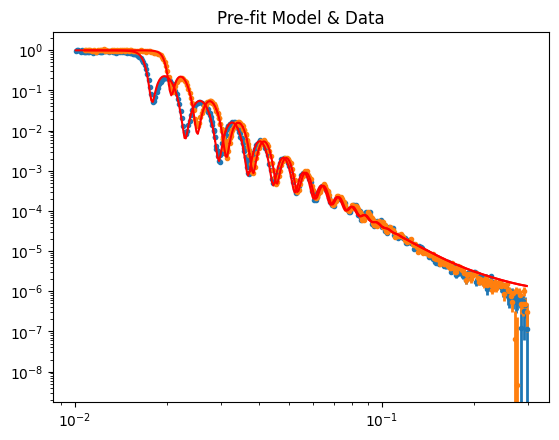

In [10]:
# Show the plot for the pre-fit state:
fig,ax=global_objective.plot()
plt.title("Pre-fit Model & Data")
plt.xscale('log')
plt.yscale('log')

In [11]:
from pathos.pools import ProcessPool

pool = ProcessPool(nodes=4)
fitter = CurveFitter(objective=global_objective)
fitter.fit(method='differential_evolution', workers=pool.map)

0it [00:00, ?it/s]/Users/r2i/Documents/VFP_desktop/VFP/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
-4480.1940200878325: : 22it [01:37,  4.45s/it]


             message: Optimization terminated successfully.
             success: True
                 fun: -4490.660815649137
                   x: [ 9.316e-01  1.750e-07  4.136e+01  7.575e+02
                        2.116e+00  1.668e+00  2.306e+01  9.630e-01
                        1.434e-07]
                 nit: 22
                nfev: 3385
          population: [[ 9.326e-01  2.029e-07 ...  9.584e-01  1.552e-07]
                       [ 9.271e-01  2.939e-07 ...  9.635e-01  1.205e-07]
                       ...
                       [ 9.322e-01  2.208e-07 ...  9.712e-01  6.546e-08]
                       [ 9.282e-01  1.623e-07 ...  9.942e-01  3.294e-07]]
 population_energies: [-4.491e+03 -4.386e+03 ... -4.471e+03 -4.344e+03]
                 jac: [-2.251e+02  1.492e+06  1.258e+00 -1.737e+00
                        2.022e+00  2.717e+01  1.151e+01 -8.617e+02
                        4.950e+05]
               covar: [[ 5.208e-06  2.170e-12 ...  1.028e-06  1.207e-11]
                 

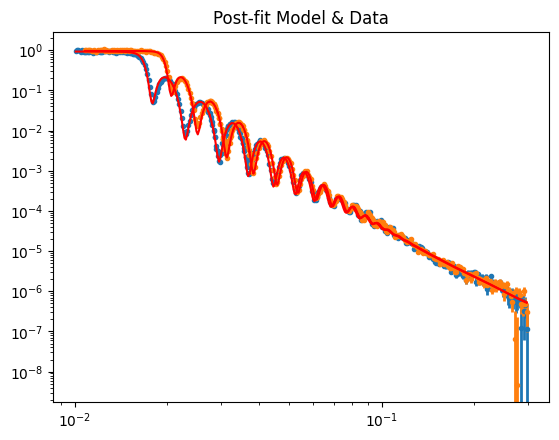

In [12]:
# Show the plot for the pre-fit state:
fig,ax=global_objective.plot()
plt.title("Post-fit Model & Data")
plt.xscale('log')
plt.yscale('log')

In [13]:
print(global_objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:   'Si_int'    , value=0.931574 +/- 0.00228, bounds=[0.9, 1.1]>
<Parameter:   'Si_bkg'    , value=1.74983e-07 +/- 5.95e-08, bounds=[1e-09, 1e-06]>
<Parameter:'sio2_thickness', value=41.3638 +/- 1.66 , bounds=[10.0, 50.0]>
<Parameter:'Ir_thickness' , value=757.452 +/- 0.109, bounds=[600.0, 850.0]>
<Parameter:'si_sio2_roughness', value=2.11617 +/- 5.15 , bounds=[1.0, 5.0]>
<Parameter:'sio2_Ir_roughness', value=1.66787 +/- 0.188, bounds=[1.0, 6.0]>
<Parameter:'Ir_air_roughness', value=23.0569 +/- 0.116, bounds=[6.0, 35.0]>
<Parameter:   'Air_int'   , value=0.963037 +/- 0.00195, bounds=[0.9, 1.1]>
<Parameter:   'Air_bkg'   , value=1.4335e-07 +/- 5.8e-08, bounds=[1e-09, 1e-06]>


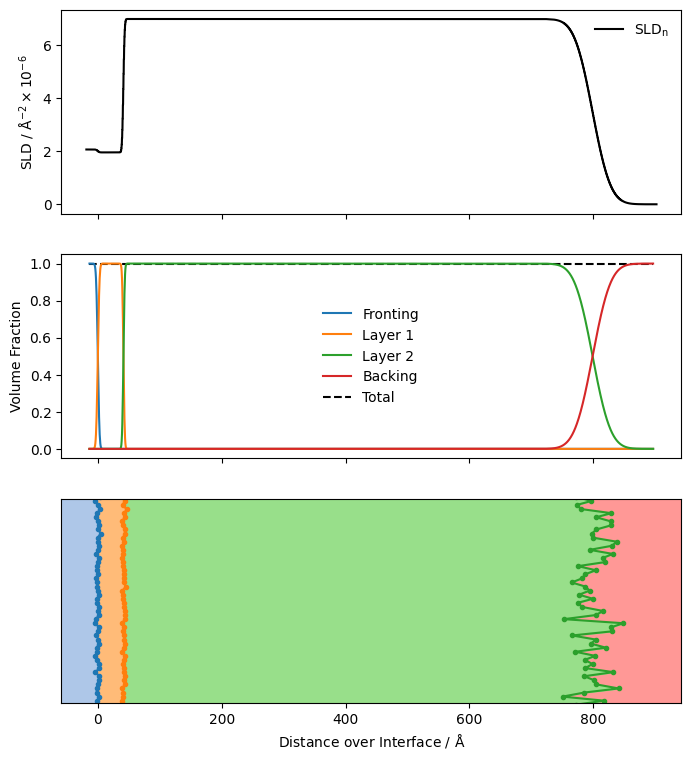

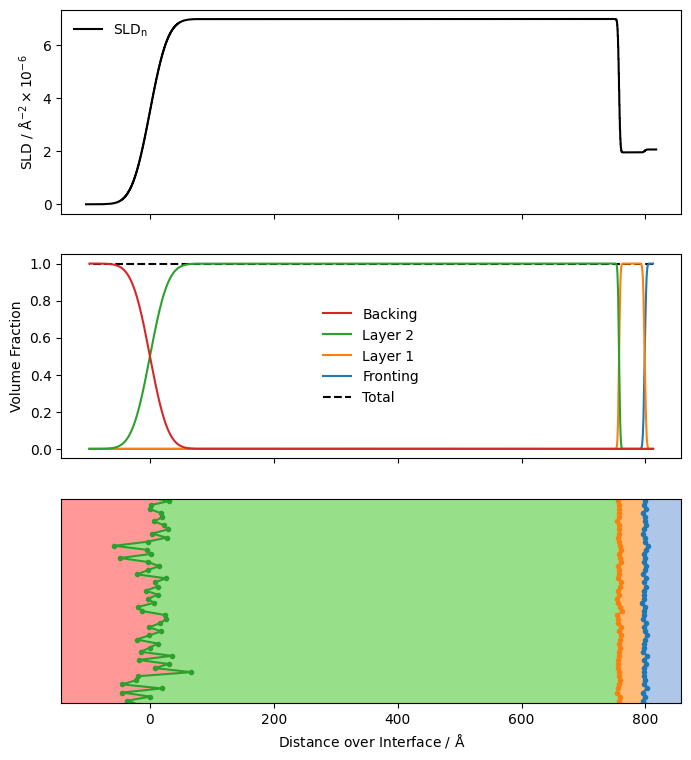

In [14]:
## Note: this might need updating with new plotting features.
Si_vfp.plot()
plt.show()
Air_vfp.plot()
plt.show()

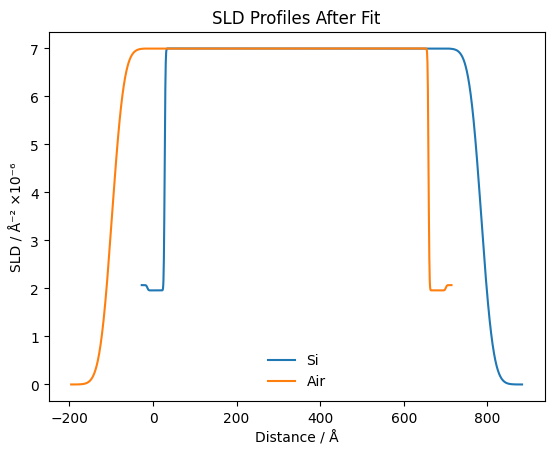

In [15]:
fig, ax = plt.subplots()
for vfp_obj, label in [(Si_vfp, "Si"), (Air_vfp, "Air")]:
    z, all_slds = vfp_obj.z_and_sld()
    ax.plot(z + vfp_obj.sld_offset(), all_slds[:, 0], label=label)  # sld_n
ax.set_ylabel("SLD / Å⁻² ×10⁻⁶")
ax.set_xlabel("Distance / Å")
ax.legend(frameon=False)
plt.title("SLD Profiles After Fit")
plt.show()

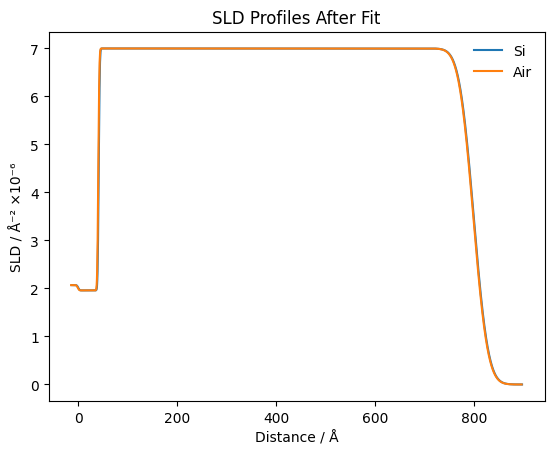

In [16]:
fig, ax = plt.subplots()
for vfp_obj, label, offset, rev in [(Si_vfp, "Si", 0, 1), (Air_vfp, "Air", -798, -1)]:
    z, all_slds = vfp_obj.z_and_sld()
    ax.plot((z + offset)*rev, all_slds[:, 0], label=label)  # sld_n
ax.set_ylabel("SLD / Å⁻² ×10⁻⁶")
ax.set_xlabel("Distance / Å")
ax.legend(frameon=False)
plt.title("SLD Profiles After Fit")
plt.show()